# MARBERT

In [ ]:
import re
import html
import random
import unicodedata
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score, classification_report
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm

# =============================
# 1️⃣ Reproducibility
# =============================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =============================
# 2️⃣ Arabic Preprocessing
# =============================
ARABIC_DIACRITICS = re.compile(r'[\u0617-\u061A\u064B-\u0652]')

def preprocess_arabic(text):

    if text is None:
        return ""

    text = str(text)
    text = html.unescape(text)
    text = text.lower()

    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'<[^>]+>', ' ', text)

    text = ARABIC_DIACRITICS.sub('', text)
    text = text.replace('ـ', '')

    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'[يى]', 'ي', text)
    text = re.sub(r'[ؤ]', 'و', text)
    text = re.sub(r'[ئ]', 'ي', text)

    text = ''.join(ch for ch in text if unicodedata.category(ch)[0] != 'C')

    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# =============================
# 3️⃣ Load Data
# =============================
train_df = pd.read_csv("Alldialect_Train_set.csv")
val_df   = pd.read_csv("Alldialect_Val_set.csv")
test_df  = pd.read_csv("End-to-End_dataset_test.csv")

train_df.columns = train_df.columns.str.strip()
val_df.columns   = val_df.columns.str.strip()
test_df.columns  = test_df.columns.str.strip()

for df, name in [(train_df,"train"),(val_df,"val"),(test_df,"test")]:
    if "commentaire" not in df.columns or "dialect" not in df.columns:
        raise ValueError(f"{name}.csv must contain columns 'commentaire' and 'dialect'")

# =============================
# 4️⃣ Dialect Mapping
# =============================
DIALECT_MAP = {
    0: "Egypt",
    1: "Sudan",
    2: "Lebanon",
    3: "Tunisia"
}

dialect_mapping = {v: k for k, v in DIALECT_MAP.items()}
label_names = list(DIALECT_MAP.values())
num_labels = len(label_names)

for df in [train_df, val_df, test_df]:
    df["dialect"] = df["dialect"].astype(str).str.strip()
    df["label"] = df["dialect"].map(dialect_mapping)

    if df["label"].isnull().any():
        raise ValueError(f"Invalid dialect labels found: {set(df['dialect'].unique())}")

# =============================
# 5️⃣ Preprocessing
# =============================
train_df["commentaire"] = train_df["commentaire"].map(preprocess_arabic)
val_df["commentaire"]   = val_df["commentaire"].map(preprocess_arabic)
test_df["commentaire"]  = test_df["commentaire"].map(preprocess_arabic)

# =============================
# 6️⃣ Tokenizer
# =============================
MODEL_NAME = "UBC-NLP/MARBERT"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128
BATCH_SIZE = 16

class DialectDataset(Dataset):

    def __init__(self, df):
        self.texts = df["commentaire"].tolist()
        self.labels = df["label"].astype(int).tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_loader = DataLoader(DialectDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(DialectDataset(val_df), batch_size=BATCH_SIZE)
test_loader  = DataLoader(DialectDataset(test_df), batch_size=BATCH_SIZE)

# =============================
# 7️⃣ Model
# =============================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

model.to(device)

# =============================
# 8️⃣ Training Setup
# =============================
criterion = torch.nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=2e-5)

EPOCHS = 5
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

scaler = torch.cuda.amp.GradScaler()

# =============================
# 9️⃣ Training Loop
# =============================
best_f1 = 0
patience = 2
counter = 0

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with torch.cuda.amp.autocast():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

    print("Train Loss:", total_loss / len(train_loader))

    # Validation
    model.eval()
    preds, true = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            true.extend(labels.cpu().numpy())

    f1 = f1_score(true, preds, average="macro")
    print("Validation Macro F1:", f1)

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_dialect_model.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

# =============================
# 🔟 Test Evaluation
# =============================
model.load_state_dict(torch.load("best_dialect_model.pt"))
model.eval()

preds, true = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=1)

        preds.extend(predictions.cpu().numpy())
        true.extend(labels.cpu().numpy())

print("\nFinal Test Results:")

print(classification_report(true, preds, target_names=label_names, digits=4))
print("Macro F1:", f1_score(true, preds, average="macro"))

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Train Loss: 0.3243415812470925
Validation Macro F1: 0.8856260843181732


Epoch 4:   0%|          | 0/1184 [00:00<?, ?it/s]/tmp/ipykernel_13365/3118727985.py:195: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 4: 100%|██████████| 1184/1184 [03:14<00:00,  6.08it/s]


Train Loss: 0.1790530675506169
Validation Macro F1: 0.903871633376473


Epoch 5:   0%|          | 0/1184 [00:00<?, ?it/s]/tmp/ipykernel_13365/3118727985.py:195: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 5: 100%|██████████| 1184/1184 [03:14<00:00,  6.10it/s]


Train Loss: 0.08512592781335115
Validation Macro F1: 0.9068086902891145

Final Test Results:
              precision    recall  f1-score   support

       Egypt     0.9010    0.8273    0.8626       110
       Sudan     0.9737    0.9653    0.9695       691
     Lebanon     0.9459    0.9685    0.9570       920
     Tunisia     0.9671    0.9567    0.9619       646

    accuracy                         0.9578      2367
   macro avg     0.9469    0.9294    0.9377      2367
weighted avg     0.9577    0.9578    0.9576      2367

Macro F1: 0.9377347839824035



Confusion Matrix:
[[ 91   5  13   1]
 [  3 667  17   4]
 [  5   8 891  16]
 [  2   5  21 618]]


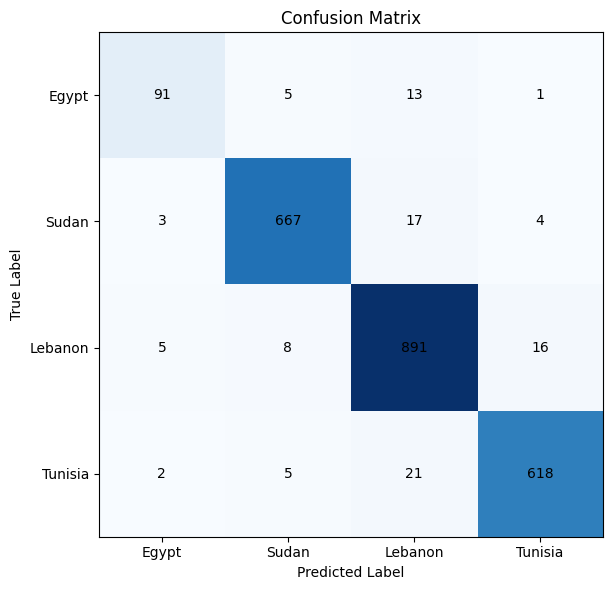

In [ ]:
# =============================
# Confusion Matrix
# =============================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(true, preds)

print("\nConfusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(label_names)))
ax.set_yticks(np.arange(len(label_names)))

ax.set_xticklabels(label_names)
ax.set_yticklabels(label_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

# كتابة الأرقام داخل المصفوفة
for i in range(len(label_names)):
    for j in range(len(label_names)):
        ax.text(j, i, cm[i, j],
                ha="center",
                va="center",
                color="black")

plt.tight_layout()
plt.show()

In [ ]:


# =============================
# Save Model to Google Drive
# =============================

import os
import json

try:
    from google.colab import drive
    drive.mount('/content/drive')

    SAVE_PATH = "/content/drive/MyDrive/dialect_stage1_marbert"

except:

    SAVE_PATH = "./dialect_stage1_marbert"

os.makedirs(SAVE_PATH, exist_ok=True)

print("\nSaving model to:", SAVE_PATH)

# حفظ النموذج
model.save_pretrained(SAVE_PATH)

# حفظ tokenizer
tokenizer.save_pretrained(SAVE_PATH)

# حفظ dialect mapping
with open(os.path.join(SAVE_PATH, "dialect_mapping.json"), "w", encoding="utf-8") as f:
    json.dump(dialect_mapping, f, ensure_ascii=False)

print("Model and tokenizer saved successfully!")

Mounted at /content/drive

Saving model to: /content/drive/MyDrive/dialect_stage1_marbert


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved successfully!


# AraBERTv2

In [ ]:

import re
import html
import random
import unicodedata
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score, classification_report
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm

# =============================
# 1️⃣ Reproducibility
# =============================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =============================
# 2️⃣ Arabic Preprocessing
# =============================
ARABIC_DIACRITICS = re.compile(r'[\u0617-\u061A\u064B-\u0652]')

def preprocess_arabic(text):

    if text is None:
        return ""

    text = str(text)
    text = html.unescape(text)
    text = text.lower()

    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'<[^>]+>', ' ', text)

    text = ARABIC_DIACRITICS.sub('', text)
    text = text.replace('ـ', '')

    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'[يى]', 'ي', text)
    text = re.sub(r'[ؤ]', 'و', text)
    text = re.sub(r'[ئ]', 'ي', text)

    text = ''.join(ch for ch in text if unicodedata.category(ch)[0] != 'C')

    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# =============================
# 3️⃣ Load Data
# =============================
train_df = pd.read_csv("Alldialect_Train_set.csv")
val_df   = pd.read_csv("Alldialect_Val_set.csv")
test_df  = pd.read_csv("End-to-End_dataset_test.csv")

train_df.columns = train_df.columns.str.strip()
val_df.columns   = val_df.columns.str.strip()
test_df.columns  = test_df.columns.str.strip()

for df, name in [(train_df,"train"),(val_df,"val"),(test_df,"test")]:
    if "commentaire" not in df.columns or "dialect" not in df.columns:
        raise ValueError(f"{name}.csv must contain columns 'commentaire' and 'dialect'")

# =============================
# 4️⃣ Dialect Mapping
# =============================
DIALECT_MAP = {
    0: "Egypt",
    1: "Sudan",
    2: "Lebanon",
    3: "Tunisia"
}

dialect_mapping = {v: k for k, v in DIALECT_MAP.items()}
label_names = list(DIALECT_MAP.values())
num_labels = len(label_names)

for df in [train_df, val_df, test_df]:
    df["dialect"] = df["dialect"].astype(str).str.strip()
    df["label"] = df["dialect"].map(dialect_mapping)

    if df["label"].isnull().any():
        raise ValueError(f"Invalid dialect labels found: {set(df['dialect'].unique())}")

# =============================
# 5️⃣ Preprocessing
# =============================
train_df["commentaire"] = train_df["commentaire"].map(preprocess_arabic)
val_df["commentaire"]   = val_df["commentaire"].map(preprocess_arabic)
test_df["commentaire"]  = test_df["commentaire"].map(preprocess_arabic)

# =============================
# 6️⃣ Tokenizer
# =============================
MODEL_NAME = "aubmindlab/bert-base-arabertv2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128
BATCH_SIZE = 16

class DialectDataset(Dataset):

    def __init__(self, df):
        self.texts = df["commentaire"].tolist()
        self.labels = df["label"].astype(int).tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_loader = DataLoader(DialectDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(DialectDataset(val_df), batch_size=BATCH_SIZE)
test_loader  = DataLoader(DialectDataset(test_df), batch_size=BATCH_SIZE)

# =============================
# 7️⃣ Model
# =============================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

model.to(device)

# =============================
# 8️⃣ Training Setup
# =============================
criterion = torch.nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=2e-5)

EPOCHS = 5
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

scaler = torch.cuda.amp.GradScaler()

# =============================
# 9️⃣ Training Loop
# =============================
best_f1 = 0
patience = 2
counter = 0

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with torch.cuda.amp.autocast():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

    print("Train Loss:", total_loss / len(train_loader))

    # Validation
    model.eval()
    preds, true = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            true.extend(labels.cpu().numpy())

    f1 = f1_score(true, preds, average="macro")
    print("Validation Macro F1:", f1)

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_dialect_model.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

# =============================
# 🔟 Test Evaluation
# =============================
model.load_state_dict(torch.load("best_dialect_model.pt"))
model.eval()

preds, true = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=1)

        preds.extend(predictions.cpu().numpy())
        true.extend(labels.cpu().numpy())

print("\nFinal Test Results:")

print(classification_report(true, preds, target_names=label_names, digits=4))
print("Macro F1:", f1_score(true, preds, average="macro"))

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Train Loss: 0.20670686348819653
Validation Macro F1: 0.854357637592818


Epoch 4:   0%|          | 0/1184 [00:00<?, ?it/s]/tmp/ipykernel_1461/3784218289.py:195: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 4: 100%|██████████| 1184/1184 [02:52<00:00,  6.85it/s]


Train Loss: 0.24062214214103045
Validation Macro F1: 0.8607454332770303


Epoch 5:   0%|          | 0/1184 [00:00<?, ?it/s]/tmp/ipykernel_1461/3784218289.py:195: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 5: 100%|██████████| 1184/1184 [02:53<00:00,  6.84it/s]


Train Loss: 0.22710761363693588
Validation Macro F1: 0.8559524572022332

Final Test Results:
              precision    recall  f1-score   support

       Egypt     0.7849    0.6636    0.7192       110
       Sudan     0.9535    0.9493    0.9514       691
     Lebanon     0.9230    0.9380    0.9305       920
     Tunisia     0.9401    0.9474    0.9437       646

    accuracy                         0.9311      2367
   macro avg     0.9004    0.8746    0.8862      2367
weighted avg     0.9301    0.9311    0.9304      2367

Macro F1: 0.8862000950402956


# CamelBERT

In [ ]:

import re
import html
import random
import unicodedata
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score, classification_report
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm

# =============================
# 1️⃣ Reproducibility
# =============================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =============================
# 2️⃣ Arabic Preprocessing
# =============================
ARABIC_DIACRITICS = re.compile(r'[\u0617-\u061A\u064B-\u0652]')

def preprocess_arabic(text):

    if text is None:
        return ""

    text = str(text)
    text = html.unescape(text)
    text = text.lower()

    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'<[^>]+>', ' ', text)

    text = ARABIC_DIACRITICS.sub('', text)
    text = text.replace('ـ', '')

    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'[يى]', 'ي', text)
    text = re.sub(r'[ؤ]', 'و', text)
    text = re.sub(r'[ئ]', 'ي', text)

    text = ''.join(ch for ch in text if unicodedata.category(ch)[0] != 'C')

    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# =============================
# 3️⃣ Load Data
# =============================
train_df = pd.read_csv("Alldialect_Train_set.csv")
val_df   = pd.read_csv("Alldialect_Val_set.csv")
test_df  = pd.read_csv("End-to-End_dataset_test.csv")

train_df.columns = train_df.columns.str.strip()
val_df.columns   = val_df.columns.str.strip()
test_df.columns  = test_df.columns.str.strip()

for df, name in [(train_df,"train"),(val_df,"val"),(test_df,"test")]:
    if "commentaire" not in df.columns or "dialect" not in df.columns:
        raise ValueError(f"{name}.csv must contain columns 'commentaire' and 'dialect'")

# =============================
# 4️⃣ Dialect Mapping
# =============================
DIALECT_MAP = {
    0: "Egypt",
    1: "Sudan",
    2: "Lebanon",
    3: "Tunisia"
}

dialect_mapping = {v: k for k, v in DIALECT_MAP.items()}
label_names = list(DIALECT_MAP.values())
num_labels = len(label_names)

for df in [train_df, val_df, test_df]:
    df["dialect"] = df["dialect"].astype(str).str.strip()
    df["label"] = df["dialect"].map(dialect_mapping)

    if df["label"].isnull().any():
        raise ValueError(f"Invalid dialect labels found: {set(df['dialect'].unique())}")

# =============================
# 5️⃣ Preprocessing
# =============================
train_df["commentaire"] = train_df["commentaire"].map(preprocess_arabic)
val_df["commentaire"]   = val_df["commentaire"].map(preprocess_arabic)
test_df["commentaire"]  = test_df["commentaire"].map(preprocess_arabic)

# =============================
# 6️⃣ Tokenizer
# =============================
MODEL_NAME = "CAMeL-Lab/bert-base-arabic-camelbert-da"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128
BATCH_SIZE = 16

class DialectDataset(Dataset):

    def __init__(self, df):
        self.texts = df["commentaire"].tolist()
        self.labels = df["label"].astype(int).tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_loader = DataLoader(DialectDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(DialectDataset(val_df), batch_size=BATCH_SIZE)
test_loader  = DataLoader(DialectDataset(test_df), batch_size=BATCH_SIZE)

# =============================
# 7️⃣ Model
# =============================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

model.to(device)

# =============================
# 8️⃣ Training Setup
# =============================
criterion = torch.nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=2e-5)

EPOCHS = 5
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

scaler = torch.cuda.amp.GradScaler()

# =============================
# 9️⃣ Training Loop
# =============================
best_f1 = 0
patience = 2
counter = 0

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with torch.cuda.amp.autocast():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()

    print("Train Loss:", total_loss / len(train_loader))

    # Validation
    model.eval()
    preds, true = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = torch.argmax(outputs.logits, dim=1)

            preds.extend(predictions.cpu().numpy())
            true.extend(labels.cpu().numpy())

    f1 = f1_score(true, preds, average="macro")
    print("Validation Macro F1:", f1)

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_dialect_model.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

# =============================
# 🔟 Test Evaluation
# =============================
model.load_state_dict(torch.load("best_dialect_model.pt"))
model.eval()

preds, true = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=1)

        preds.extend(predictions.cpu().numpy())
        true.extend(labels.cpu().numpy())

print("\nFinal Test Results:")

print(classification_report(true, preds, target_names=label_names, digits=4))
print("Macro F1:", f1_score(true, preds, average="macro"))

Using device: cuda


config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Train Loss: 0.18538920476252363
Validation Macro F1: 0.8648967784385554


Epoch 4:   0%|          | 0/1184 [00:00<?, ?it/s]/tmp/ipykernel_1461/3574805194.py:195: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 4: 100%|██████████| 1184/1184 [02:38<00:00,  7.47it/s]


Train Loss: 0.1899496820390325
Validation Macro F1: 0.8686638077555568


Epoch 5:   0%|          | 0/1184 [00:00<?, ?it/s]/tmp/ipykernel_1461/3574805194.py:195: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 5: 100%|██████████| 1184/1184 [02:38<00:00,  7.48it/s]


Train Loss: 0.09702744717533524
Validation Macro F1: 0.865787852778998

Final Test Results:
              precision    recall  f1-score   support

       Egypt     0.7273    0.7273    0.7273       110
       Sudan     0.9643    0.9378    0.9508       691
     Lebanon     0.9176    0.9446    0.9309       920
     Tunisia     0.9483    0.9365    0.9424       646

    accuracy                         0.9303      2367
   macro avg     0.8894    0.8865    0.8878      2367
weighted avg     0.9308    0.9303    0.9304      2367

Macro F1: 0.8878473127730677
